# library yang dibutuhkan

In [2]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.common.exceptions import NoSuchElementException
from selenium.webdriver.support.ui import WebDriverWait
import time, pandas as pd

# Pengumpulan Data tempat Wisata Raja Ampat (Papua Barat Daya)

In [5]:
# Argumen agar menerima review
options = Options()
options.add_argument("--lang=id")
options.add_argument("--accept-language=id-ID,id;q=0.9")

#options = Options()
#options.add_argument('--lang=id')
#options.add_argument('accept-languange=id-ID, id')
driver = webdriver.Chrome(options=options)

# Memanggil lokasi digmaps lewat URL (Raja Ampat)
driver.get("https://maps.app.goo.gl/CaadXaT32wHoCijR9")
time.sleep(3)

# Cek apakah lokasi benar-benar ada
try:
    nama_tempat = driver.find_element(By.CLASS_NAME, "DUwDvf").text.strip()
except NoSuchElementException:
    nama_tempat = "unknown"

# Klik tombol More Reviews jika ada
try:
    more_reviews = WebDriverWait(driver, 10).until(
        EC.element_to_be_clickable((By.XPATH, "//span[contains(text(), 'Ulasan lainnya') or contains(text(), 'More reviews')]/ancestor::button")))
    more_reviews.click()
    print("[INFO] Klik tombol More reviews.")
    time.sleep(3)
except:
    print("[INFO] Tidak ada tombol More reviews.")

# Scraping data di Gmaps
reviews, seen = [], set()
while len(reviews) < 50:
    for c in driver.find_elements(By.CSS_SELECTOR, 'div.jftiEf'):
        user_el = c.find_elements(By.CLASS_NAME, 'd4r55')
        review_el = c.find_elements(By.CLASS_NAME, 'wiI7pd')
        rating_el = c.find_elements(By.CLASS_NAME, 'kvMYJc')
        # Skip jika review kosong
        if not review_el or not review_el[0].text.strip():
            continue
        user = user_el[0].text if user_el else 'Unknown'
        review = review_el[0].text.strip()
        rating = rating_el[0].get_attribute('aria-label').split()[0] if rating_el else 'Unknown'
        if (user, review) not in seen:
            seen.add((user, review))
            reviews.append({
                'nama_tempat': nama_tempat,
                'user': user,
                'review': review,
                'rating': rating
            })
    try:
        driver.execute_script(
            "arguments[0].scrollIntoView();",
            driver.find_elements(By.CSS_SELECTOR, 'div.jftiEf')[-1]
        )
    except:
        break
    time.sleep(3)


[INFO] Tidak ada tombol More reviews.


In [6]:
# Menyimpan hasil dari scraping GMAPS
pd.DataFrame(reviews).to_csv("ulasan_Raja_Ampat.csv", index=False)
print(f"[INFO] {len(reviews)} ulasan berhasil didapatkan dan di eksport")
driver.quit

[INFO] 50 ulasan berhasil didapatkan dan di eksport


<bound method ChromiumDriver.quit of <selenium.webdriver.chrome.webdriver.WebDriver (session="08173884fe0bd3bc57ce73e46073496d")>>

# Pre Processing Data Ulasan Tempat Wisata (Raja Ampat)

In [8]:
import numpy as np 
import pandas as pd 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder 
from sklearn.preprocessing import StandardScaler
import ydata_profiling

In [19]:
data_ulasan = pd.read_csv(r'D:\Semester 5\Penambangan Data\Praktikum\ulasan_Raja_Ampat.xls')


In [20]:
data_ulasan

,nama_tempat,user,review,rating
0,Kabupaten Raja Ampat,Su padmi (padmi),Masya alloh luar biasa Indah pemandangannya la...,5
1,Kabupaten Raja Ampat,Hendrika Maria,Yang indah tapi akan lenyap karena PT Gag Nike...,5
2,Kabupaten Raja Ampat,MnR Bf Antik Berkicau,Pesona pemandangan alam Raja ampat papua barat,5
3,Kabupaten Raja Ampat,Yuli Linggau,"Pemandangan yang sangat indah,air lautnya jern...",5
4,Kabupaten Raja Ampat,Nabila Aslam Lubis,BAGUUUS BGT TEMPATNYA! SEMOGA BISA KESINI LG D...,5
5,Kabupaten Raja Ampat,Hanafi Zakariyya,Bagus pemandangannya tapi sayang nya sekarang ...,5
6,Kabupaten Raja Ampat,Uswatun Hasanah LuQman,Tidak ada kata yg bisa menggambarkan keindahan...,5
7,Kabupaten Raja Ampat,Isurra Noriko Kira V2.0,Raja Ampat sangat cocok untuk snorkeling dan d...,5
8,Kabupaten Raja Ampat,Yoga,Jika saya pergi ke Papua lebih baik destinasin...,5
9,Kabupaten Raja Ampat,Satriya Kresna Aji,"Bagus baget asli, dari sorong ke pelabuhan men...",5


In [25]:
data_ulasan.isna().sum()

nama_tempat    0
user           0
review         0
rating         0
dtype: int64

In [26]:
def label_sentimen(r):
    if r >= 4:
        return 'positif'
    elif r == 3:
        return 'netral'
    else:
        return 'negatif'

data_ulasan['sentimen'] = data['rating'].apply(label_sentimen)


In [33]:
data_ulasan['review'] = data['review'].str.lower()

In [46]:
#Menghapus simbol, angka, emoji
import re

def cleaning(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

data_ulasan['review_clean'] = data_ulasan['review'].apply(cleaning)

In [47]:
data_ulasan['token'] = data_ulasan['review_clean'].apply(lambda x: x.split())

In [31]:
!pip install Sastrawi

   ---------------------------------------- 0.0/209.7 kB ? eta -:--:--
   - -------------------------------------- 10.2/209.7 kB ? eta -:--:--
   - -------------------------------------- 10.2/209.7 kB ? eta -:--:--
   ----- --------------------------------- 30.7/209.7 kB 187.9 kB/s eta 0:00:01
   ----------- --------------------------- 61.4/209.7 kB 328.2 kB/s eta 0:00:01
   ----------------------------------- -- 194.6/209.7 kB 845.5 kB/s eta 0:00:01
   -------------------------------------- 209.7/209.7 kB 797.7 kB/s eta 0:00:00


In [48]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stopwords = set(StopWordRemoverFactory().get_stop_words())

data_ulasan['token'] = data_ulasan['token'].apply(
    lambda x: [kata for kata in x if kata not in stopwords]
)

In [49]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer = StemmerFactory().create_stemmer()

data_ulasan['token'] = data_ulasan['token'].apply(
    lambda x: [stemmer.stem(kata) for kata in x]
)

In [50]:
data_ulasan['review_final'] = data_ulasan['token'].apply(lambda x: " ".join(x))

In [51]:
data_ulasan[['review', 'review_final']].head()


,review,review_final
0,masya alloh luar biasa indah pemandangannya la...,masya alloh luar biasa indah pandang laut yg b...
1,yang indah tapi akan lenyap karena pt gag nike...,indah lenyap pt gag nikel yg rupa anak usaha p...
2,pesona pemandangan alam raja ampat papua barat,pesona pandang alam raja ampat papua barat
3,"pemandangan yang sangat indah,air lautnya jern...",pandang sangat indahair laut jernih sekaliakan...
4,baguuus bgt tempatnya! semoga bisa kesini lg d...,baguuus bgt tempat moga kesini lg ngambil trip...


In [52]:
display(data_ulasan)

,nama_tempat,user,review,rating,sentimen,review_clean,token,review_final
0,Kabupaten Raja Ampat,Su padmi (padmi),masya alloh luar biasa indah pemandangannya la...,5,positif,masya alloh luar biasa indah pemandangannya la...,"[masya, alloh, luar, biasa, indah, pandang, la...",masya alloh luar biasa indah pandang laut yg b...
1,Kabupaten Raja Ampat,Hendrika Maria,yang indah tapi akan lenyap karena pt gag nike...,5,positif,yang indah tapi akan lenyap karena pt gag nike...,"[indah, lenyap, pt, gag, nikel, yg, rupa, anak...",indah lenyap pt gag nikel yg rupa anak usaha p...
2,Kabupaten Raja Ampat,MnR Bf Antik Berkicau,pesona pemandangan alam raja ampat papua barat,5,positif,pesona pemandangan alam raja ampat papua barat,"[pesona, pandang, alam, raja, ampat, papua, ba...",pesona pandang alam raja ampat papua barat
3,Kabupaten Raja Ampat,Yuli Linggau,"pemandangan yang sangat indah,air lautnya jern...",5,positif,pemandangan yang sangat indahair lautnya jerni...,"[pandang, sangat, indahair, laut, jernih, seka...",pandang sangat indahair laut jernih sekaliakan...
4,Kabupaten Raja Ampat,Nabila Aslam Lubis,baguuus bgt tempatnya! semoga bisa kesini lg d...,5,positif,baguuus bgt tempatnya semoga bisa kesini lg de...,"[baguuus, bgt, tempat, moga, kesini, lg, ngamb...",baguuus bgt tempat moga kesini lg ngambil trip...
5,Kabupaten Raja Ampat,Hanafi Zakariyya,bagus pemandangannya tapi sayang nya sekarang ...,5,positif,bagus pemandangannya tapi sayang nya sekarang ...,"[bagus, pandang, sayang, nya, sekarang, rusak]",bagus pandang sayang nya sekarang rusak
6,Kabupaten Raja Ampat,Uswatun Hasanah LuQman,tidak ada kata yg bisa menggambarkan keindahan...,5,positif,tidak ada kata yg bisa menggambarkan keindahan...,"[kata, yg, gambar, indah, langit, laut, raja, ...",kata yg gambar indah langit laut raja ampat pa...
7,Kabupaten Raja Ampat,Isurra Noriko Kira V2.0,raja ampat sangat cocok untuk snorkeling dan d...,5,positif,raja ampat sangat cocok untuk snorkeling dan d...,"[raja, ampat, sangat, cocok, snorkeling, divin...",raja ampat sangat cocok snorkeling diving surg...
8,Kabupaten Raja Ampat,Yoga,jika saya pergi ke papua lebih baik destinasin...,5,positif,jika saya pergi ke papua lebih baik destinasin...,"[pergi, papua, lebih, baik, destinasi, raja, a...",pergi papua lebih baik destinasi raja ampat su...
9,Kabupaten Raja Ampat,Satriya Kresna Aji,"bagus baget asli, dari sorong ke pelabuhan men...",5,positif,bagus baget asli dari sorong ke pelabuhan menu...,"[bagus, baget, asli, sorong, labuh, tuju, labu...",bagus baget asli sorong labuh tuju labuh waisa...


# Pelabelan

In [53]:
def label_sentimen(rating):
    rating = int(rating)
    if rating >= 4:
        return 1
    elif rating == 3:
        return 0
    else:
        return -1

data_ulasan['sentimen'] = data_ulasan['rating'].apply(label_sentimen)
data_ulasan['sentimen'].value_counts()

sentimen
 1    46
-1     3
 0     1
Name: count, dtype: int64

In [54]:
data_ulasan['label_sentimen'] = data_ulasan['sentimen'].map({
    1: 'Positif',
    0: 'Netral',
    -1: 'Negatif'
})

In [60]:
data_ulasan[['nama_tempat', 'user', 'review', 'review_clean', 'review_final', 'label_sentimen']]

,nama_tempat,user,review,review_clean,review_final,label_sentimen
0,Kabupaten Raja Ampat,Su padmi (padmi),masya alloh luar biasa indah pemandangannya la...,masya alloh luar biasa indah pemandangannya la...,masya alloh luar biasa indah pandang laut yg b...,Positif
1,Kabupaten Raja Ampat,Hendrika Maria,yang indah tapi akan lenyap karena pt gag nike...,yang indah tapi akan lenyap karena pt gag nike...,indah lenyap pt gag nikel yg rupa anak usaha p...,Positif
2,Kabupaten Raja Ampat,MnR Bf Antik Berkicau,pesona pemandangan alam raja ampat papua barat,pesona pemandangan alam raja ampat papua barat,pesona pandang alam raja ampat papua barat,Positif
3,Kabupaten Raja Ampat,Yuli Linggau,"pemandangan yang sangat indah,air lautnya jern...",pemandangan yang sangat indahair lautnya jerni...,pandang sangat indahair laut jernih sekaliakan...,Positif
4,Kabupaten Raja Ampat,Nabila Aslam Lubis,baguuus bgt tempatnya! semoga bisa kesini lg d...,baguuus bgt tempatnya semoga bisa kesini lg de...,baguuus bgt tempat moga kesini lg ngambil trip...,Positif
5,Kabupaten Raja Ampat,Hanafi Zakariyya,bagus pemandangannya tapi sayang nya sekarang ...,bagus pemandangannya tapi sayang nya sekarang ...,bagus pandang sayang nya sekarang rusak,Positif
6,Kabupaten Raja Ampat,Uswatun Hasanah LuQman,tidak ada kata yg bisa menggambarkan keindahan...,tidak ada kata yg bisa menggambarkan keindahan...,kata yg gambar indah langit laut raja ampat pa...,Positif
7,Kabupaten Raja Ampat,Isurra Noriko Kira V2.0,raja ampat sangat cocok untuk snorkeling dan d...,raja ampat sangat cocok untuk snorkeling dan d...,raja ampat sangat cocok snorkeling diving surg...,Positif
8,Kabupaten Raja Ampat,Yoga,jika saya pergi ke papua lebih baik destinasin...,jika saya pergi ke papua lebih baik destinasin...,pergi papua lebih baik destinasi raja ampat su...,Positif
9,Kabupaten Raja Ampat,Satriya Kresna Aji,"bagus baget asli, dari sorong ke pelabuhan men...",bagus baget asli dari sorong ke pelabuhan menu...,bagus baget asli sorong labuh tuju labuh waisa...,Positif


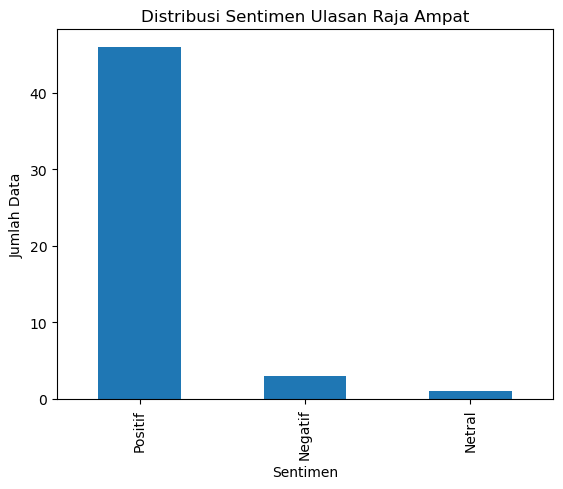

In [58]:
import matplotlib.pyplot as plt
%matplotlib inline

data_ulasan['label_sentimen'].value_counts().plot(kind='bar')
plt.title('Distribusi Sentimen Ulasan Raja Ampat')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Data')
plt.show()

# Visualisasi Sentiment Positif dan Negative

In [61]:
data_pn = data_ulasan[data_ulasan['label_sentimen'].isin(['Positif', 'Negatif'])]

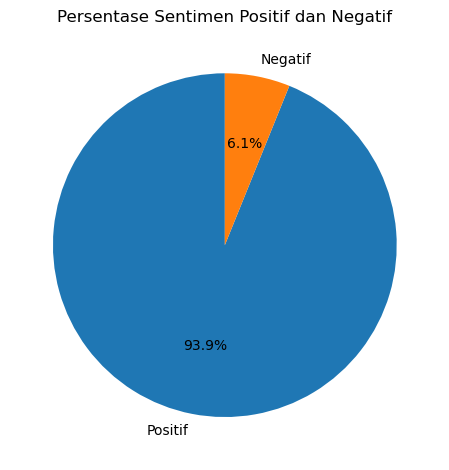

In [67]:
import matplotlib.pyplot as plt

plt.figure()
data_pn['label_sentimen'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Persentase Sentimen Positif dan Negatif')
plt.ylabel('')
plt.tight_layout()
plt.show()


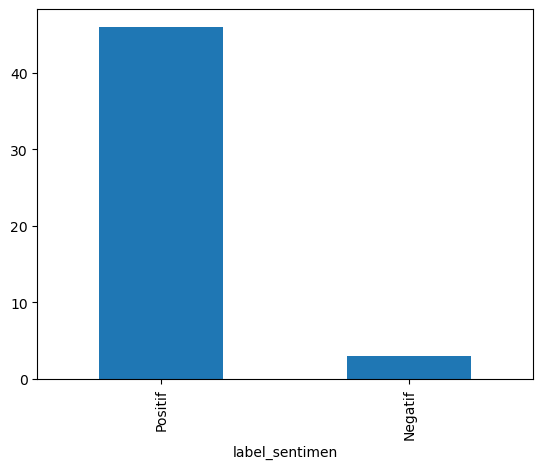

In [68]:
plt.figure()
data_pn['label_sentimen'].value_counts().plot(kind='bar')
plt.show()

# Visualisasi wordcloud masing-masing sentiment

In [69]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [70]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [71]:
# pisahkan berdasarkan sentiment
data_pos = data_ulasan[data_ulasan['label_sentimen'] == 'Positif']
data_neg = data_ulasan[data_ulasan['label_sentimen'] == 'Negatif']

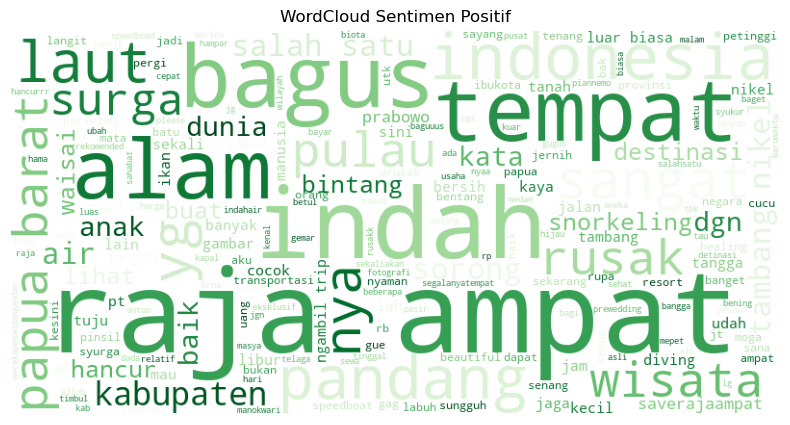

In [72]:
# wordcloud sentimen positif
text_pos = ' '.join(data_pos['review_final'])

wc_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens'
).generate(text_pos)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos)
plt.axis('off')
plt.title('WordCloud Sentimen Positif')
plt.show()

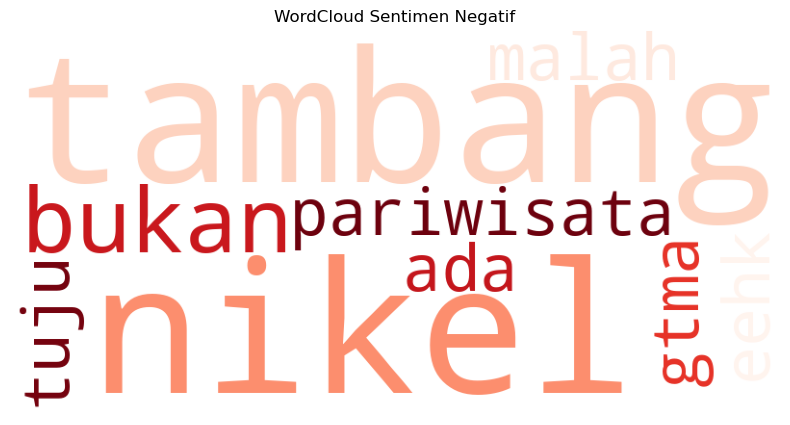

In [74]:
# wordcloud sentimen negatif
text_neg = ' '.join(data_neg['review_final'])

wc_neg = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate(text_neg)

plt.figure(figsize=(10,5))
plt.imshow(wc_neg)
plt.axis('off')
plt.title('WordCloud Sentimen Negatif')
plt.show()
